# 04 â€” Modeling & Hyperparameter Tuning
Seattle Airbnb Price Prediction â€” CSE437

Covers report sections **5 (Modeling and Validation)** and **6 (Hyperparameter Tuning)**.
Saves tuned model pipelines to `models/` for the evaluation notebook.

In [20]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

model_df = pd.read_csv('../data/processed/model_ready.csv', low_memory=False)

with open('../data/processed/final_features.txt') as f:
    lines = f.read().splitlines()
FINAL_NUMERIC_FEATURES = [c for c in lines[0].replace('NUMERIC:', '').split(',') if c]
FINAL_CATEGORICAL_FEATURES = [c for c in lines[1].replace('CATEGORICAL:', '').split(',') if c]

print("Loaded model_ready.csv:", model_df.shape)
print("Numeric features:", len(FINAL_NUMERIC_FEATURES))
print("Categorical features:", len(FINAL_CATEGORICAL_FEATURES))


Loaded model_ready.csv: (7576, 11)
Numeric features: 8
Categorical features: 1


## 5.1 Validation strategy
70/15/15 train/val/test split, fixed random seed, 5-fold CV inside the hyperparameter search on the train set.

In [21]:
X = model_df[FINAL_NUMERIC_FEATURES + FINAL_CATEGORICAL_FEATURES]
y = model_df['log_price']

# Hold out 15% for one final evaluation; model selection uses 5-fold CV on the remaining data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)

print(f"Train/CV: {X_train.shape}, Test: {X_test.shape}")

# Persist the split so notebook 05 reproduces the exact same test set
X_test.to_csv('../data/processed/X_test.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)


Train/CV: (6439, 9), Test: (1137, 9)


In [22]:
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), FINAL_NUMERIC_FEATURES),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), FINAL_CATEGORICAL_FEATURES)
])


## 5.2 Baseline

In [23]:
baseline = DummyRegressor(strategy='median')
baseline.fit(X_train, y_train)
baseline_pred_log = baseline.predict(X_test)
print(f"Baseline (predict median log_price) RMSE (log space): {rmse(y_test, baseline_pred_log):.4f}")

joblib.dump(baseline, '../models/baseline.joblib')


Baseline (predict median log_price) RMSE (log space): 0.5749


['../models/baseline.joblib']

## 5.3 Model family 1 — Ridge Regression
Linear, interpretable, assumes an additive linear relationship between scaled features and log price.

In [24]:
ridge_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', Ridge())
])

ridge_param_grid = {
    'model__alpha': np.logspace(-3, 3, 20)
}

ridge_search = GridSearchCV(
    ridge_pipe,
    ridge_param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
ridge_search.fit(X_train, y_train)

print("Search space: 20 alpha values, log-spaced 1e-3 to 1e3, 5-fold CV = 100 fits")
print("Best alpha:", ridge_search.best_params_['model__alpha'])
print("Best CV RMSE (log space):", -ridge_search.best_score_)

joblib.dump(ridge_search.best_estimator_, '../models/ridge_tuned.joblib')

Search space: 20 alpha values, log-spaced 1e-3 to 1e3, 5-fold CV = 100 fits
Best alpha: 1.438449888287663
Best CV RMSE (log space): 0.40696920577342865


['../models/ridge_tuned.joblib']

## 5.4 Model family 2 — Random Forest
Non-linear ensemble that captures interactions and non-linear effects.

In [25]:
rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])

rf_param_dist = {
    'model__n_estimators': [100, 200, 400, 600],
    'model__max_depth': [None, 5, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', 0.5]
}
# Full grid = 4*5*3*3*3 = 540 combinations; RandomizedSearchCV samples 30 with 5-fold CV = 150 fits

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=30, cv=5,
    scoring='neg_root_mean_squared_error', random_state=RANDOM_STATE, n_jobs=-1
)
rf_search.fit(X_train, y_train)

print("Best params:", rf_search.best_params_)
print("Best CV RMSE (log space):", -rf_search.best_score_)

joblib.dump(rf_search.best_estimator_, '../models/random_forest_tuned.joblib')


Best params: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': 10}
Best CV RMSE (log space): 0.3943559681019761


['../models/random_forest_tuned.joblib']

## 6.1 Hyperparameter search spaces and results

In [26]:
tuning_results = pd.DataFrame([
    {
        'model': 'Ridge', 'method': 'GridSearchCV',
        'search_space': '20 alpha values (log-spaced 1e-3 to 1e3)',
        'n_fits': '20 x 5-fold = 100',
        'best_params': str(ridge_search.best_params_),
        'best_cv_rmse_log': -ridge_search.best_score_,
    },
    {
        'model': 'RandomForest', 'method': 'RandomizedSearchCV',
        'search_space': '540 combinations (n_estimators x max_depth x min_samples_split x min_samples_leaf x max_features)',
        'n_fits': '30 sampled x 5-fold = 150',
        'best_params': str(rf_search.best_params_),
        'best_cv_rmse_log': -rf_search.best_score_,
    },
])
tuning_results.to_csv('../data/processed/tuning_results.csv', index=False)
tuning_results


,model,method,search_space,n_fits,best_params,best_cv_rmse_log
0,Ridge,GridSearchCV,20 alpha values (log-spaced 1e-3 to 1e3),20 x 5-fold = 100,{'model__alpha': np.float64(1.438449888287663)},0.406969
1,RandomForest,RandomizedSearchCV,540 combinations (n_estimators x max_depth x m...,30 sampled x 5-fold = 150,"{'model__n_estimators': 100, 'model__min_sampl...",0.394356


## 6.2 Ridge search trend

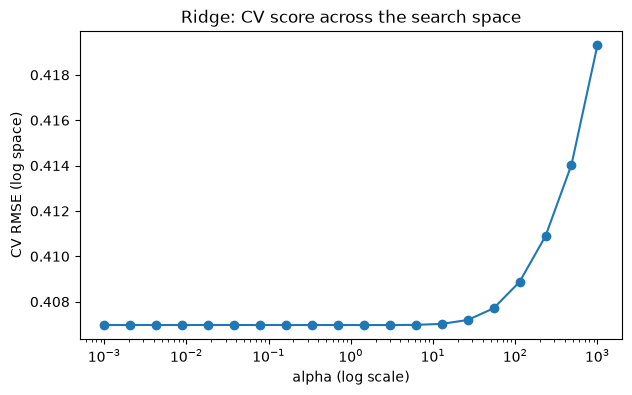

In [27]:
import matplotlib.pyplot as plt

cv_results = pd.DataFrame(ridge_search.cv_results_)
plt.figure(figsize=(7, 4))
plt.plot(cv_results['param_model__alpha'], -cv_results['mean_test_score'], marker='o')
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('CV RMSE (log space)')
plt.title('Ridge: CV score across the search space')
plt.savefig('../figures/04_ridge_alpha_search.png', dpi=120)
plt.show()
